In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib import rc
import matplotlib.gridspec as gridspec
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from PIL import Image
from matplotlib.colors import LogNorm
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.patches import Rectangle
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
import glob
import os

In [6]:
# -----------------------------------------------
# paths
# -----------------------------------------------
best_sim=200

leger=xr.open_dataset("../../FesmData/Leger2024_PaleoGris/output/regions_area_paleogris4.nc")
yelmo1=xr.open_dataset("../output/timeseries_from2D_part1.nc")
yelmo2=xr.open_dataset("/p/projects/megarun/luciagu/data/tabone2024/processed/regions_area_ensemble.nc")
rg=xr.open_dataset("/p/projects/megarun/luciagu/data/lauritzen2025/Greenland_Basins_PS_v1.4.2_8km.nc")
best=yelmo1.sel(sim=best_sim)
topo = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")


/tmp/ipykernel_1641205/2931077153.py:50: UserWarning: linewidths is ignored by contourf
  ax_map.contourf(rg["xc"], rg["yc"], rg.mask.where(rg.mask>1), levels=np.linspace(0,7,8), cmap="Pastel1", linewidths=0.5)


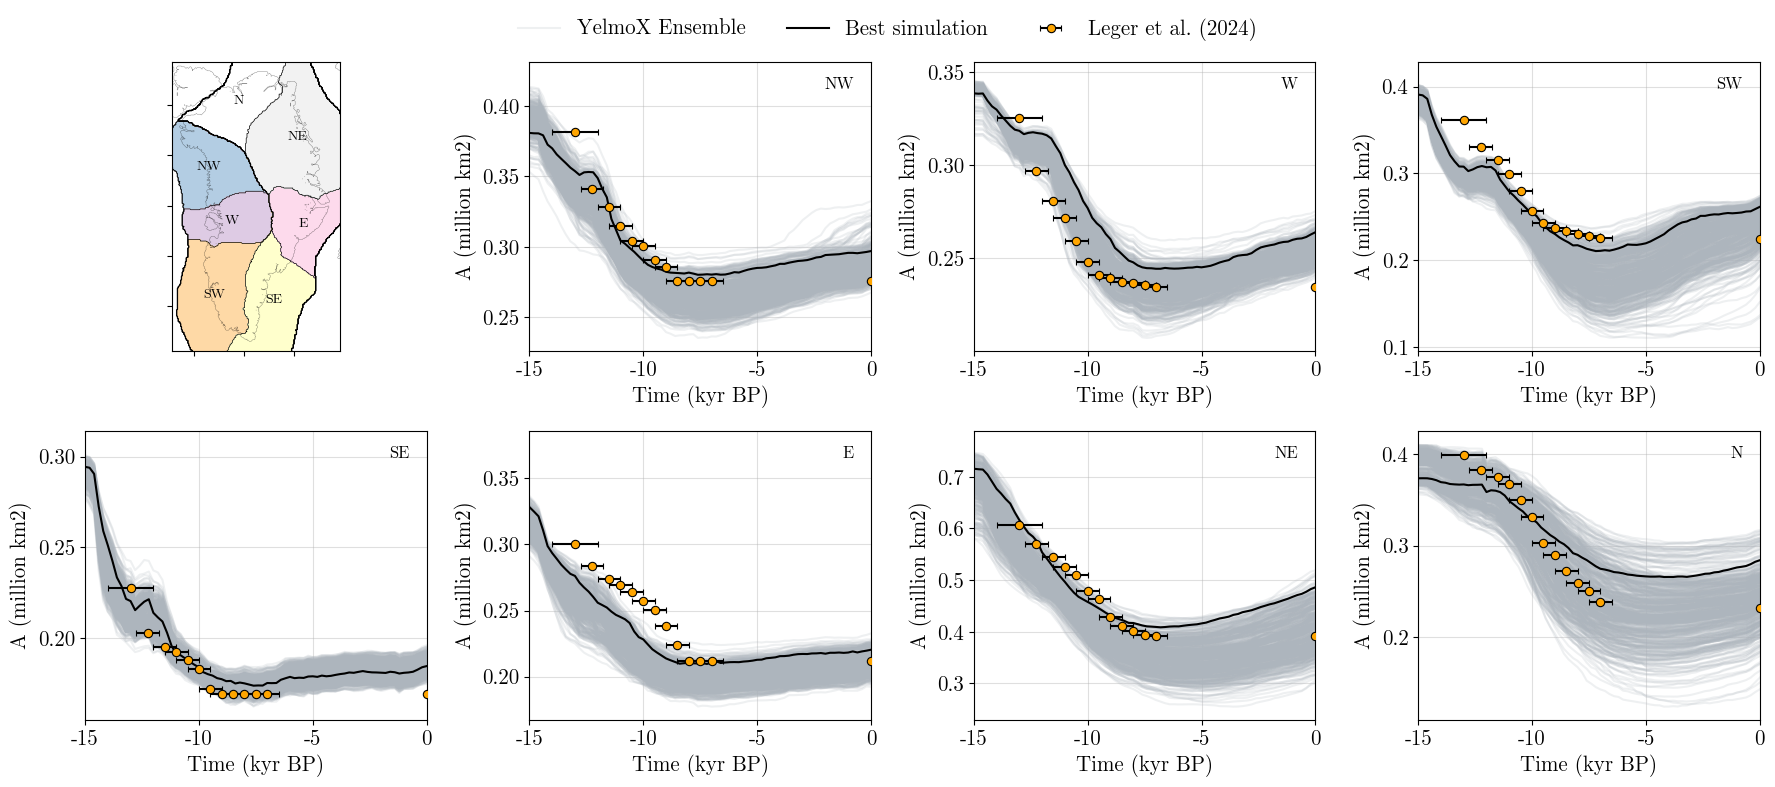

In [7]:
# Nombres de las regiones
region_names = ["NW", "W", "SW","SE","E","NE","N"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
region_ids=leger.region.values

for i, r in enumerate(region_ids):
    ax = axes[i+1]
    
    # yelmo
    j=0
    for sim_idx in yelmo1.sim.values:
        if j==0:
            ax.plot(
            yelmo1["time"]*1e-3, 
            yelmo1["A"].sel(sim=sim_idx, region=r), 
            "-", color="#adb5bd", alpha=0.2, label="YelmoX Ensemble")
        else:
            ax.plot(
            yelmo1["time"]*1e-3, 
            yelmo1["A"].sel(sim=sim_idx, region=r), 
            "-", color="#adb5bd", alpha=0.2)
        j=j+1
    # Leger (2024)
    leg=leger.sel(region=r)
    ax.errorbar(-leg["time"] * 1e-3,leg.A,xerr=leg.time_err*1e-3,fmt='o',ecolor='black',
                markersize=6,markerfacecolor='orange',markeredgecolor='black',markeredgewidth=0.8,
                capsize=2,zorder=60,label="Leger et al. (2024)")
    
    # best simulation
    ax.plot(best.time*1e-3,best.A.sel(region=r), "-", color="black",label="Best simulation")
    
    # names
    ax.text(
        0.95, 0.95, region_names[i],
        transform=ax.transAxes,  
        ha='right', va='top',
        fontsize=12, weight='bold')
    ax.grid(alpha=0.4)
    ax.set_xlabel("Time (kyr BP)")
    ax.set_ylabel("A (million km2)")
    ax.set_xlim(-15,0)

# --- mapa de regiones ---
ax_map = axes[0]

# Contornos de regiones
ax_map.contour(rg["xc"], rg["yc"], rg.mask, colors='black', linewidths=0.5)
ax_map.contourf(rg["xc"], rg["yc"], rg.mask.where(rg.mask>1), levels=np.linspace(0,7,8), cmap="Pastel1", linewidths=0.5)

ax_map.contour(topo.xc,topo.yc,topo.z_srf,levels=np.linspace(0,100,1), colors='black', linewidths=0.3, alpha=0.5)

ax_map.set_xlabel("")
ax_map.set_ylabel("")
ax_map.set_aspect('equal')
ax_map.set_xticklabels([]) 
ax_map.set_yticklabels([]) 
ax_map.grid(False)

# Añadir nombres de región en lugar de números
for i, r in enumerate(region_ids):
    ys, xs = np.where(rg.mask == r)
    if len(xs) > 0:
        cx = rg["xc"].values[xs].mean()
        cy = rg["yc"].values[ys].mean()
        ax_map.text(cx, cy, region_names[i], color="black", ha="center", va="center",
                    fontsize=10, weight="bold")

# --- Quitar subplots vacíos si los hubiera ---
for j in range(len(region_ids) + 1, len(axes)):
    axes[j].axis("off")

# --- Leyenda global ---
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [62]:
fig.savefig("../figs/ensemble_isochrones.png", dpi=300)